<a href="https://colab.research.google.com/github/nishu-0618/ML_projects/blob/main/02_decision_trees_and_pruning_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
X, y = make_classification(
    n_samples = 1000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
wild_tree = DecisionTreeClassifier(random_state=42)
wild_tree.fit(X_train, y_train)
print(f"Wild Tree DEpth: {wild_tree.get_depth()}")
print(f"Wild Tree Leaves: {wild_tree.get_n_leaves()}")
print(f"Train Accuracy: {wild_tree.score(X_train, y_train)}")
print(f"Test Accuracy: {wild_tree.score(X_test, y_test)}")

Wild Tree DEpth: 10
Wild Tree Leaves: 42
Train Accuracy: 1.0
Test Accuracy: 0.95


In [3]:
path = wild_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas = ccp_alphas[:-1]
print(f"Found {len(ccp_alphas)} candidtae alpha values to test")

Found 27 candidtae alpha values to test


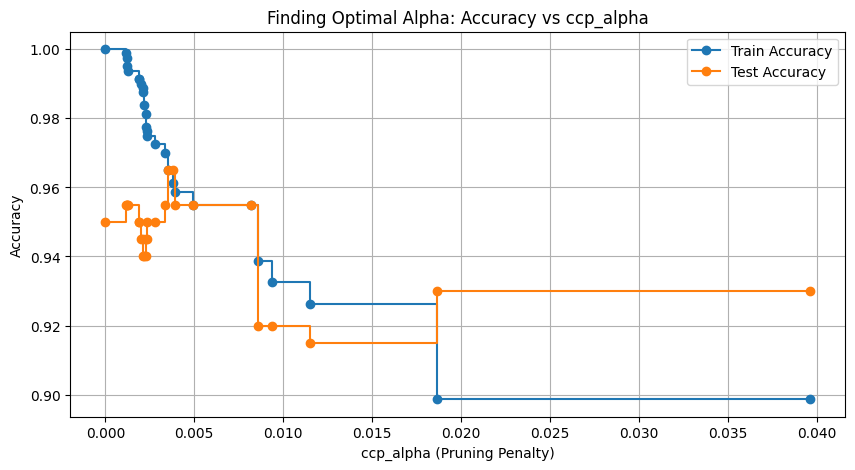

In [5]:
clfs = []
train_score = []
test_score = []
for alpha in ccp_alphas:
  clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
  clf.fit(X_train, y_train)
  clfs.append(clf)
  train_score.append(clf.score(X_train, y_train))
  test_score.append(clf.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, train_score, marker='o', label="Train Accuracy", drawstyle="steps-post")
plt.plot(ccp_alphas, test_score, marker='o', label="Test Accuracy", drawstyle="steps-post")
plt.xlabel("ccp_alpha (Pruning Penalty)")
plt.ylabel("Accuracy")
plt.title("Finding Optimal Alpha: Accuracy vs ccp_alpha")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Find the index of the highest test accuracy
best_idx = np.argmax(test_score)
best_alpha = ccp_alphas[best_idx]
best_tree = clfs[best_idx]

print(f"Optimal Alpha: {best_alpha:.5f}")
print("--- Before vs After Pruning ---")
print(f"Wild Tree Depth:    {wild_tree.get_depth()}  --> Pruned Tree Depth:    {best_tree.get_depth()}")
print(f"Wild Tree Leaves:   {wild_tree.get_n_leaves()} --> Pruned Tree Leaves:   {best_tree.get_n_leaves()}")
print(f"Wild Test Accuracy: {wild_tree.score(X_test, y_test):.2f} --> Pruned Test Accuracy: {best_tree.score(X_test, y_test):.2f}")

Optimal Alpha: 0.00353
--- Before vs After Pruning ---
Wild Tree Depth:    10  --> Pruned Tree Depth:    6
Wild Tree Leaves:   42 --> Pruned Tree Leaves:   12
Wild Test Accuracy: 0.95 --> Pruned Test Accuracy: 0.96


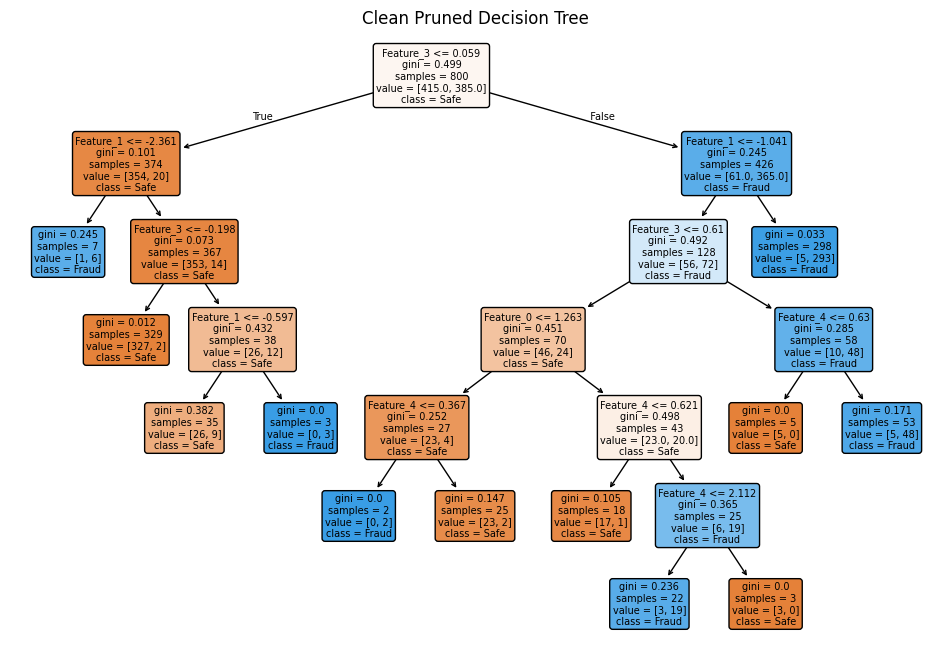

In [8]:
plt.figure(figsize=(12, 8))
plot_tree(
    best_tree,
    filled=True,
    feature_names=[f"Feature_{i}" for i in range(5)],
    class_names=["Safe", "Fraud"],
    rounded=True
)
plt.title("Clean Pruned Decision Tree")
plt.show()